## Thông tin sinh viên
- Lớp: DHKHMT19A
- MSSV: 23722291
- Họ tên: Cao Huỳnh Trung Kiên
- Số máy: 10
- Tên file: 23722291_CHTrungKien_M10.ipynb

### **1. Chuẩn bị và tiền xử lý dữ liệu**

In [1]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings  
from sklearn.preprocessing import OneHotEncoder
warnings.filterwarnings("ignore") 

In [2]:
# Đọc dữ liệu
df = pd.read_csv('students_performance_practice.csv')
df.head()

,StudentID,Age,StudyHours,AttendanceRate,AssignmentsCompleted,OnlineActivity,SleepHours,SocialActivity,MidtermScore,FinalScore,GPA,GradePoints,PerformanceIndex,Major,City,Gender
0,1,24,32.0,91.3,59.1,7.7,5.8,2.9,71.2,92.8,3.67,91.87,82.00,IT,Cần Thơ,Female
1,2,21,15.5,78.4,77.9,6.3,6.2,0.2,59.8,82.2,2.94,73.52,70.98,CE,Hà Nội,Male
2,3,30,29.7,90.0,67.2,6.2,8.1,2.2,65.5,93.9,3.61,90.34,79.68,SE,Hà Nội,Male
3,4,28,30.0,89.8,96.6,4.5,6.1,0.0,61.5,87.0,3.74,93.57,74.24,CS,Cần Thơ,Male
4,5,25,9.7,71.2,89.1,5.9,7.6,3.1,58.0,76.4,3.20,80.04,67.24,CS,Đà Nẵng,Male


In [3]:
# Kiểm tra dữ liệu thiếu
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             10000 non-null  int64  
 1   Age                   10000 non-null  int64  
 2   StudyHours            9500 non-null   float64
 3   AttendanceRate        9500 non-null   float64
 4   AssignmentsCompleted  10000 non-null  float64
 5   OnlineActivity        9500 non-null   float64
 6   SleepHours            10000 non-null  float64
 7   SocialActivity        10000 non-null  float64
 8   MidtermScore          10000 non-null  float64
 9   FinalScore            10000 non-null  float64
 10  GPA                   10000 non-null  float64
 11  GradePoints           10000 non-null  float64
 12  PerformanceIndex      10000 non-null  float64
 13  Major                 10000 non-null  object 
 14  City                  10000 non-null  object 
 15  Gender              

StudentID                 0
Age                       0
StudyHours              500
AttendanceRate          500
AssignmentsCompleted      0
OnlineActivity          500
SleepHours                0
SocialActivity            0
MidtermScore              0
FinalScore                0
GPA                       0
GradePoints               0
PerformanceIndex          0
Major                     0
City                      0
Gender                    0
dtype: int64

In [4]:
# Xừ lý dữ liệu thiếu
df['StudyHours'].fillna(df['StudyHours'].median(), inplace=True)
df['AttendanceRate'].fillna(df['AttendanceRate'].median(), inplace=True)
df['OnlineActivity'].fillna(df['OnlineActivity'].median(), inplace=True)

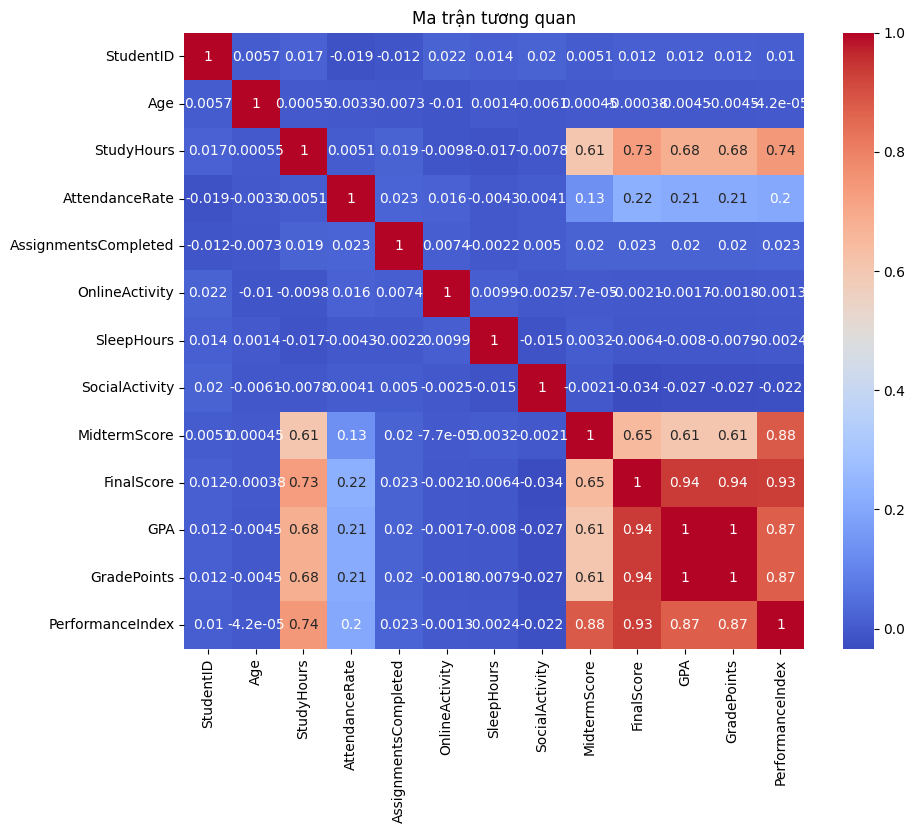

In [5]:
# Tính tương quan
num_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Ma trận tương quan')
plt.show()

In [6]:
# Loại bỏ thuộc tính tuyến tính
corr_matrix = df[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
drop_cols.append('StudentID')
print('Các cột bị loại bỏ:', drop_cols)

Các cột bị loại bỏ: ['GradePoints', 'StudentID']


In [7]:
# Chuẩn hóa dữ liệu
features = [col for col in num_cols if col not in drop_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

### **2. Phân nhóm KMeans**

In [8]:
# Huấn luyện KMeans với K=4, thêm cột Cluster
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = labels
df['Cluster'].value_counts()

Cluster
0    3019
2    2525
3    2367
1    2089
Name: count, dtype: int64

### **3. Đánh giá mô hình**

In [9]:
#  Tính Silhouette
sil = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette score (K={k}): {sil:.2f}")


Silhouette score (K=4): 0.11


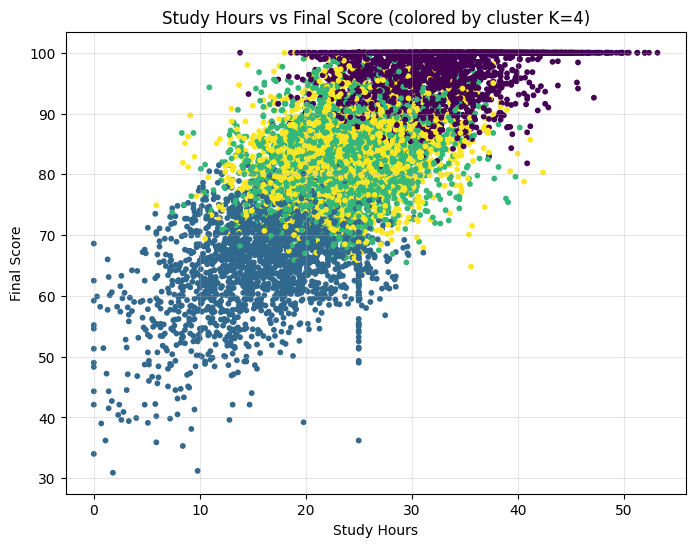

In [10]:
# Vẽ scatter (StudyHours vs FinalScore)
plt.figure(figsize=(8, 6))
plt.scatter(df["StudyHours"], df["FinalScore"], c=df["Cluster"], s=10)
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title(f"Study Hours vs Final Score (colored by cluster K={k})")
plt.grid(alpha=0.3)
plt.show()

### **4. Xác định số nhóm tối ưu**

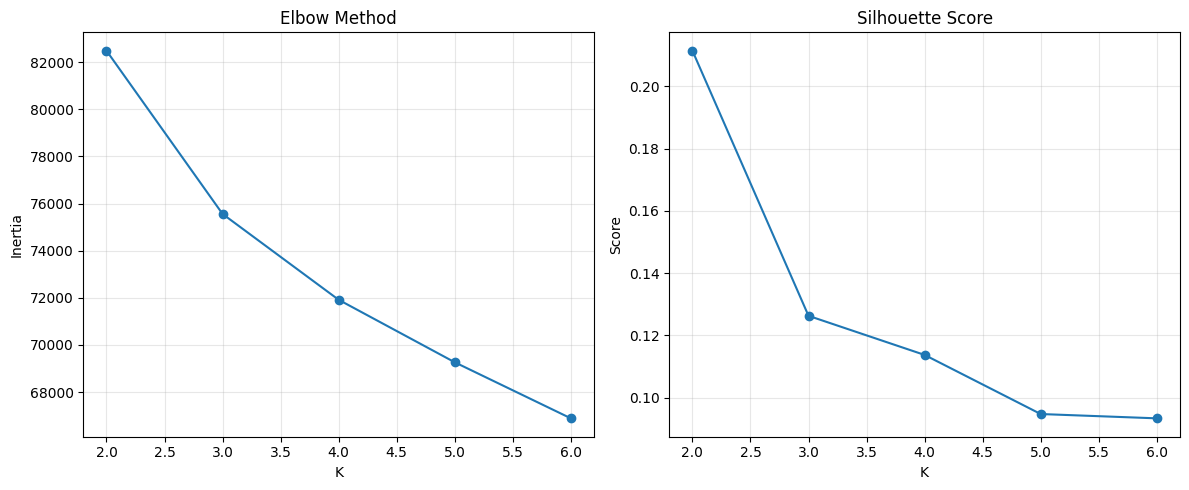

Inertia: {2: 82484.31741351605, 3: 75558.07981032363, 4: 71916.70986009296, 5: 69265.78193051254, 6: 66887.5683262995}
Silhouette: {2: np.float64(0.21148201171726355), 3: np.float64(0.1262634020528502), 4: np.float64(0.11369780585587054), 5: np.float64(0.0946993030437821), 6: np.float64(0.09331417525300213)}


In [13]:
inertias = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Inertia:", dict(zip(K_range, inertias)))
print("Silhouette:", dict(zip(K_range, sil_scores)))

> *Dựa vào 2 biểu đồ ta thấy được k tốt nhất là 5!*

### **5. Phân tích kết quả**

In [12]:
# Tính trung bình theo nhóm
group_means = df.groupby('Cluster')[features].mean().round(2)
group_means

,Age,StudyHours,AttendanceRate,AssignmentsCompleted,OnlineActivity,SleepHours,SocialActivity,MidtermScore,FinalScore,GPA,PerformanceIndex
Cluster,,,,,,,,,,,
0,23.97,32.45,87.40,79.61,6.00,7.01,2.51,65.62,97.02,3.85,81.32
1,24.07,16.27,81.92,78.80,6.07,7.01,2.63,45.69,65.58,2.60,55.64
2,20.69,24.00,84.49,80.13,6.03,6.98,2.63,55.23,83.02,3.32,69.13
3,27.52,24.27,84.23,78.15,6.02,6.99,2.41,55.51,83.28,3.32,69.39


> **Nhận xét:**
- Nhóm 0 có thời gian tự học và điểm số cao -> sinh viên chăm chỉ, thành tích tốt.
- Nhóm 1 có tỷ lệ đi học thấp và ngủ ít -> cần hỗ trợ về cân bằng thời gian học - nghỉ.
- Nhóm 2 trung bình về mọi mặt -> nhóm ổn định, hiệu quả học tập trung bình.
- Nhóm 1 có hoạt động xã hội cao, nhưng điểm thấp -> có thể thiếu tập trung học. 